In [9]:
# Polynomial Regression

In [ ]:
# Polynomial Regression is a regression algorithm that models the relationship between a dependent(y) and independent variable(x) as nth degree polynomial.
# Y= b0 + b1 * x1 + b2 * x1^2 + b2 * x1^3 +.......+ bn * x1^n

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
dataset = pd.read_csv("polynomial_salary_data.csv")
dataset.head(3)

,Level,Salary
0,1,35805
1,2,20900
2,3,25480


In [4]:
dataset.corr()

,Level,Salary
Level,1.000000,0.968468
Salary,0.968468,1.000000


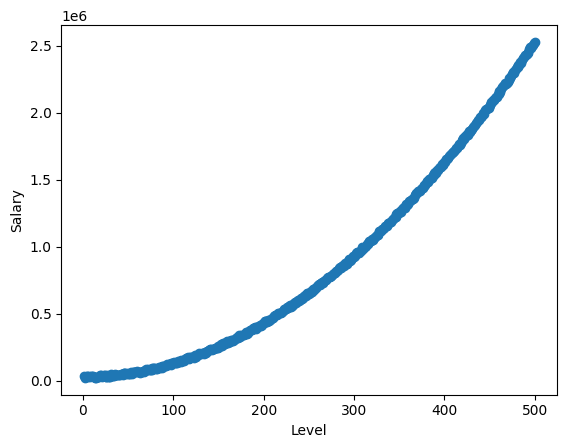

In [5]:
plt.scatter(dataset["Level"], dataset["Salary"])
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

In [6]:
x = dataset[["Level"]]
y = dataset["Salary"]

In [7]:
from sklearn.preprocessing import PolynomialFeatures

In [8]:
pf = PolynomialFeatures(degree = 2)
pf.fit(x)
x = pf.transform(x)

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
lr.score(x_test, y_test)*100

99.99522179499087

In [ ]:
# y = m1x1 + m2x2^2 + c
# y = 16.43811469 * x1 + 9.9688672 * x2^2 + 28338.588357014232

In [14]:
lr.coef_

array([ 0.        , 16.43811469,  9.9688672 ])

In [15]:
lr.intercept_

np.float64(28338.588357014232)

In [16]:
prd = lr.predict(x)

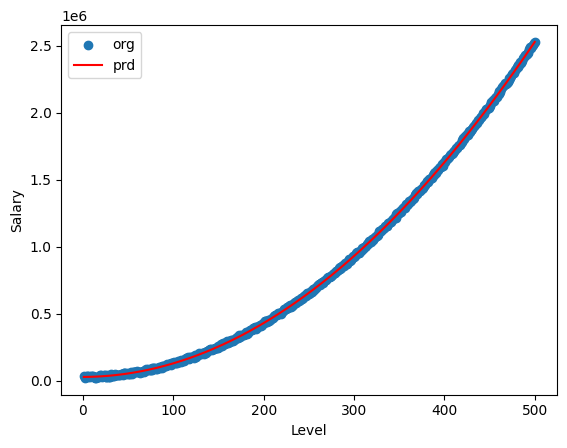

In [24]:
plt.scatter(dataset["Level"], dataset["Salary"], label = "org")
plt.plot(dataset["Level"], prd, c = 'red', label = "prd")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [29]:
test = pf.transform([[45]])
test

C:\Users\PRANAV\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[1.000e+00, 4.500e+01, 2.025e+03]])

In [30]:
lr.predict(test)

array([49265.25958919])